# 03. PyTorch Computer Vision

This notebook builds an image classification workflow on the Fashion MNIST dataset using PyTorch and TorchVision — covering data loading, a baseline linear model, and a full training/evaluation loop.

- `torchvision.datasets` — provides ready-to-use vision datasets with built-in train/test splits
- `torch.utils.data.DataLoader` — batches and shuffles data for training
- `nn.Sequential` — chains layers into a simple feed-forward model

**Note:** This notebook trains on CPU by default; a CUDA/ROCm device is only used if detected in the setup cell.

**Resources**
1. Notebook: https://www.learnpytorch.io/03_pytorch_computer_vision/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s

## Setup & Environment Check

Import the core libraries and detect the available device up front so every tensor and model can be moved to the right place later in the notebook.

- `torch.cuda.is_available()` — checks for a CUDA/ROCm-capable GPU and falls back to CPU otherwise
- `warnings.filterwarnings("ignore")` — suppresses noisy library warnings so the output stays readable
- `DEVICE` — global variable set here and reused throughout the notebook for `.to(DEVICE)` calls

**Note:** This model is trained entirely on `"cpu"` later in the notebook — `DEVICE` is detected here for reference and timing comparisons, not used to move the model or data.

In [27]:
# Capture runtime details so later cells can choose the right device.
import platform
import torch
from torch import nn
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision  import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Keep notebook output focused on the example results.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Training and inference will use the CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


## Getting the Dataset (TorchVision)

Download the Fashion MNIST dataset via `torchvision.datasets` — a set of 28x28 grayscale images across 10 clothing categories, already split into train and test sets.

- `datasets.FashionMNIST(root=..., train=True/False, download=True, transform=...)` — downloads (if not cached) and loads the dataset
- `transform=transforms.ToTensor()` — converts each PIL image to a `torch.Tensor` and scales pixel values to `[0, 1]`
- `target_transform` — optional transform applied to labels; left as `None` here since labels are already integers

**Note:** Both `train_data` and `test_data` are downloaded to a local `data/` folder — subsequent runs skip the download if the folder already exists.

In [28]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

len(train_data), len(test_data)

(60000, 10000)

In [29]:
image = train_data[0][0]
print(image.shape, image.min(), image.max())
print(f"Label: {train_data[0][1]}, Class Name: {train_data.classes[train_data[0][1]]}")

torch.Size([1, 28, 28]) tensor(0.) tensor(1.)
Label: 9, Class Name: Ankle boot


In [30]:
image, label = train_data[0]
print(f"Image shape: {image.shape}, Label: {label}, Class Name: {train_data.classes[label]}")
image

Image shape: torch.Size([1, 28, 28]), Label: 9, Class Name: Ankle boot


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

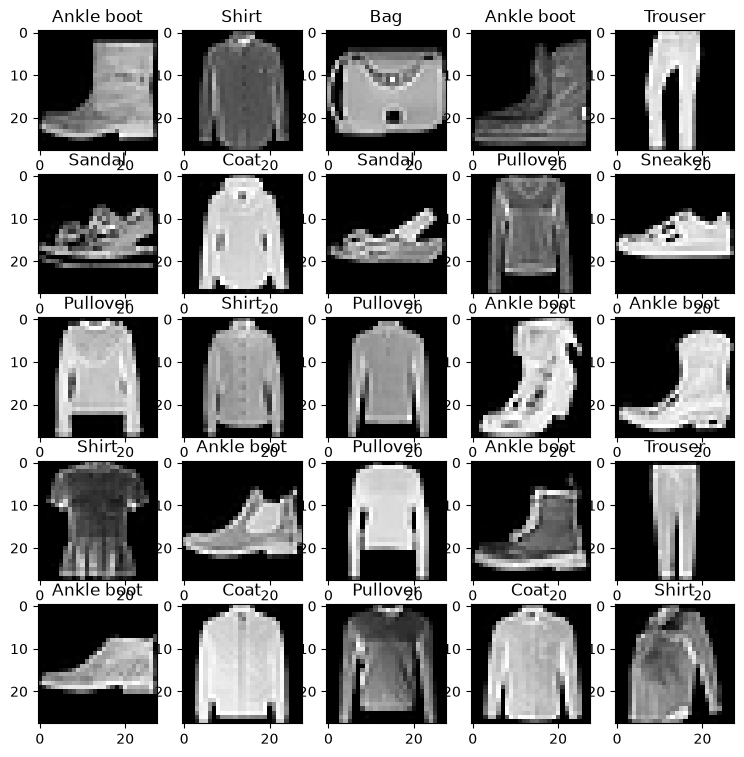

In [31]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 5, 5
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(train_data.classes[label])

## Prepare DataLoader

Wrap the datasets in `DataLoader` objects so training happens in mini-batches instead of one image at a time.

- `DataLoader(dataset=..., batch_size=32, shuffle=True/False)` — turns a `Dataset` into an iterable of batches
- `shuffle=True` (train) — reshuffles data each epoch to reduce overfitting and improve generalization
- `shuffle=False` (test) — order doesn't matter for evaluation, so shuffling is skipped
- `BATCH_SIZE = 32` — a common default; smaller batches update weights more often at the cost of noisier gradients

**Note:** `next(iter(train_dataloader))` pulls a single batch out for inspection — it does not advance the DataLoader for the actual training loop later, since a fresh iterator is created each epoch.

In [32]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

# Turn the training and test datasets into DataLoaders (From PyTorch Dataset to Python iterable)
# Using Mini-batches to speed up training and reduce memory usage and to improve generalization (more chances to escape local minima/update weights more often): batch size = 32 (default)

train_dataloader = torch.utils.data.DataLoader(dataset=train_data, batch_size=32, shuffle=True) # Shuffle the training data to improve generalization and avoid overfitting (more chances to escape local minima/update weights more often)
test_dataloader = torch.utils.data.DataLoader(dataset=test_data, batch_size=32, shuffle=False) # No need to shuffle the test data as we are not training on it, just evaluating the model's performance on unseen data (easier).

print(f"Data: {train_data}\n\nTest data: {test_data}")
print(f"DataLoaders: {train_dataloader}\n\nTest DataLoader: {test_dataloader}\n\nBatch size: {BATCH_SIZE}\n")

# Check the first batch of training data
print(f"Length of training dataloader: {len(train_dataloader)} of {len(train_dataloader.dataset)} samples")
print(f"Length of test dataloader: {len(test_dataloader)} of {len(test_dataloader.dataset)} samples")

train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features_batch.size()}")
print(f"Labels batch shape: {train_labels_batch.size()}")

Data: Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Test data: Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()
DataLoaders: <torch.utils.data.dataloader.DataLoader object at 0x0000016A310882F0>

Test DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x0000016A30B1A7B0>

Batch size: 32

Length of training dataloader: 1875 of 60000 samples
Length of test dataloader: 313 of 10000 samples
Feature batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

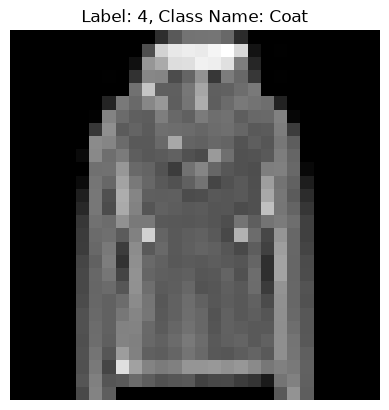

In [33]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}, Class Name: {train_data.classes[label]}")
plt.axis(False)

## Baseline model

Build the simplest possible classifier: flatten each image into a 1D vector and pass it through two linear layers.

- `nn.Flatten()` — collapses the `[channels, height, width]` image into a single `[batch_size, h*w*c]` vector
- `FashionMNISTModelV0` — a plain `nn.Sequential` stack with no activation functions between layers (a linear baseline)
- `input_shape=28*28` — matches the flattened pixel count of each Fashion MNIST image
- `model_0.state_dict()` — inspects the model's learnable parameters (weights and biases) before any training

**Note:** With no non-linear activations, this model can only learn linear decision boundaries — it's meant as a baseline to compare against more capable architectures later.

In [34]:
# Flatten layer
flatten_model = nn.Flatten()

# Get a single sample from the training batch
x = train_features_batch[0]

 # Forward pass through the flatten layer
x_flatten = flatten_model(x)

# Print the shape of the input and output tensors
print(f"Shape before flattening: {x.shape} --> [channels, height, width] where c=channels, h=height, w=width")
print(f"Shape after flattening: {x_flatten.shape} --> [batch_size, h*w*c] where h=height, w=width, c=channels")

Shape before flattening: torch.Size([1, 28, 28]) --> [channels, height, width] where c=channels, h=height, w=width
Shape after flattening: torch.Size([1, 784]) --> [batch_size, h*w*c] where h=height, w=width, c=channels


In [35]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Sequential means that the layers will be executed in the order they are defined
        self.layer_stack = nn.Sequential( 
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [36]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Create an instance of the model
model_0 = FashionMNISTModelV0(
    input_shape=28*28,  # Flattened image size (28x28 pixels = 784 from above)
    hidden_units=10,    # Number of hidden units (arbitrary choice, can be tuned)
    output_shape=len(train_data.classes)).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [37]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [38]:
dummy_x = torch.rand(size=(1, 1, 28, 28)) # Random tensor with shape [batch_size, channels, height, width]
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## Loss function and Optimizer (CrossEntropyLoss, SGD)

Define how the model measures error and how it updates its weights to reduce that error.

- `nn.CrossEntropyLoss()` — standard loss for multi-class classification; internally applies `softmax` so no activation is needed on the model's final layer
- `torch.optim.SGD(params=..., lr=0.1)` — Stochastic Gradient Descent optimizer; updates weights in the direction that reduces loss
- `accuracy_fn` — a helper (imported from `helper_functions.py`) that computes classification accuracy from predicted vs. true labels

**Note:** A learning rate of `0.1` is relatively high — appropriate here for a fast-converging baseline, but worth lowering if training becomes unstable on more complex models.

In [39]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1) # Stochastic Gradient Descent (SGD) optimizer with learning rate of 0.1


## Training Loop (Per Batch)

Run the standard PyTorch training loop: forward pass, loss calculation, backward pass, and weight update, repeated per batch and per epoch.

- `model.train()` / `model.eval()` — toggles layers like dropout/batchnorm between training and inference behavior
- `optimizer.zero_grad()` — clears gradients from the previous step before backpropagation
- `loss.backward()` — computes gradients via backpropagation
- `optimizer.step()` — applies the computed gradients to update model weights
- `torch.inference_mode()` — disables gradient tracking during evaluation for faster, memory-efficient inference

**Note:** Train and test accuracy/loss are accumulated per batch and divided by `len(dataloader)` at the end of each epoch to get the average — not divided by the number of samples.

In [40]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    """Print training time."""
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time

In [41]:
start_time = timer()

end_time = timer()
print_train_time(start=start_time, end=end_time, device=DEVICE)


Train time on cuda:0: 0.000 seconds


3.309999010525644e-05

In [42]:
from tqdm.auto import tqdm

torch.manual_seed(42)
training_time_start_on_cpu = timer()

# Set the number of epochs for training
EPOCHS = 3

# Create a training and testing loop
for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch+1}\n---------")

    train_loss, train_acc = 0, 0
    model_0.train()  # Set the model to training mode

    for batch, (X, y) in enumerate(train_dataloader):

        # Forward pass
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Backward pass
        optimizer.zero_grad()  # Zero the gradients before backward pass
        loss.backward()        # Backpropagation
        optimizer.step()       # Update the weights

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

    # Calculate average loss and accuracy for the epoch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()  # Set the model to evaluation mode
    with torch.inference_mode():  # Disable gradient calculation for inference
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test) # Forward pass
            test_loss += loss_fn(test_pred, y_test).item() # Calculate loss
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1)) # Calculate accuracy

    # Calculate average loss and accuracy for the epoch
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    # Calculate training time for the epoch
    epoch_time_end = timer()
    epoch_time = epoch_time_end - training_time_start_on_cpu

    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.3f} seconds\n")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|███▎      | 1/3 [00:04<00:08,  4.07s/it]

Train Loss: 0.5904, Train Accuracy: 79.1717
Test Loss: 0.5095, Test Accuracy: 82.0387
Epoch Time: 4.066 seconds

Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|██████▋   | 2/3 [00:08<00:04,  4.09s/it]

Train Loss: 0.4763, Train Accuracy: 83.3200
Test Loss: 0.4799, Test Accuracy: 83.1969
Epoch Time: 8.169 seconds

Epoch: 3
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 3/3 [00:12<00:00,  4.06s/it]

Train Loss: 0.4550, Train Accuracy: 84.0517
Test Loss: 0.4766, Test Accuracy: 83.4265
Epoch Time: 12.176 seconds



## Make prediction

Wrap the evaluation logic into a reusable `evaluate_model()` function that scores a trained model on any given DataLoader.

- `evaluate_model(model, data_loader, loss_fn, accuracy_fn, device)` — runs a full evaluation pass and returns average loss and accuracy
- `X.to(device), y.to(device)` — moves each batch to the target device before the forward pass
- Returns a `(loss, acc)` tuple rather than printing — keeps the function reusable for comparing multiple models later

**Note:** `device="cpu"` is the default here to match how `model_0` was trained; pass a different device explicitly if evaluating a model trained on GPU.

In [43]:
def evaluate_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device = "cpu"):
    """Evaluate a PyTorch model on a given dataset."""
    model.eval()  # Set the model to evaluation mode
    loss, acc = 0, 0

    with torch.inference_mode():  # Disable gradient calculation for inference
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)  # Move data to the specified device
            y_pred = model(X)  # Forward pass
            loss += loss_fn(y_pred, y).item()  # Calculate loss
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))  # Calculate accuracy

    # Calculate average loss and accuracy
    loss /= len(data_loader)
    acc /= len(data_loader)

    return loss, acc

evaluate_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device="cpu")

(0.4766389035854858, 83.42651757188499)

## Creating a Model on GPU (Device-Agnostic Code)

Build a second, more capable model — `FashionMNISTModelV1` — and move it to whichever device was detected earlier, using `nn.ReLU()` to introduce non-linearity.

- `nn.ReLU()` — non-linear activation inserted between linear layers so the model can learn more than a straight linear mapping
- `hidden_units=128` — increased from the baseline's `10` to give the model more learning capacity
- `.to(DEVICE)` — moves the model's parameters to the GPU if one was detected in the setup cell, or CPU otherwise
- `next(model_1.parameters()).device` — a quick way to confirm which device the model's weights actually live on

**Note:** Placing `nn.ReLU()` after the final output layer is unusual — `CrossEntropyLoss` expects raw logits, so an activation there can distort the loss calculation. Worth double-checking against the loss function's expected input.

In [44]:
# Model 1: FashionMNISTModelV1 with non-linear activation function (ReLU) and more hidden units
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),  # Non-linear activation function
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer_stack(x)
    
# Set random seed for reproducibility
torch.cuda.manual_seed(42)

# Create an instance of the model
model_1 = FashionMNISTModelV1(
    input_shape=28*28,  # Flattened image size (28x28 pixels = 784 from above)
    hidden_units=128,   # Increased number of hidden units for better learning capacity
    output_shape=len(train_data.classes)).to(DEVICE)

print(model_1)

print(f"Model Device: {next(model_1.parameters()).device}")

model_1.state_dict()

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
    (4): ReLU()
  )
)
Model Device: cuda:0


OrderedDict([('layer_stack.1.weight',
              tensor([[-1.6455e-02, -4.1883e-03, -1.4506e-02,  ...,  1.4185e-02,
                       -3.1890e-02,  2.0560e-02],
                      [-1.1099e-02, -2.7167e-02,  5.2222e-03,  ...,  2.1673e-02,
                        2.3061e-03,  2.8554e-03],
                      [ 9.7290e-03,  2.7176e-02, -1.6877e-02,  ...,  3.1042e-02,
                        3.0749e-02, -1.3650e-03],
                      ...,
                      [-2.8316e-02,  2.6531e-02, -3.5221e-02,  ...,  2.3880e-02,
                       -9.5136e-05, -2.2203e-02],
                      [ 1.8834e-02,  3.0399e-02,  1.7958e-02,  ...,  2.7959e-02,
                       -1.4946e-02,  6.1630e-03],
                      [-3.4481e-02, -2.7916e-02, -8.2649e-03,  ..., -3.1352e-02,
                        1.0393e-02,  2.9328e-02]], device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([ 7.0543e-03, -4.0150e-03,  3.5635e-02, -1.4162e-02, -2.2133e-02,
      

## Setup Loss, Optimizer, and Training Step

Redefine the loss and optimizer for `model_1`, and wrap the training logic into a reusable `train_step()` function.

- `nn.CrossEntropyLoss()` — same multi-class loss as the baseline, now paired with `model_1`
- `torch.optim.SGD(params=model_1.parameters(), lr=0.1)` — optimizer re-created for `model_1`'s parameters specifically, since optimizers are tied to a fixed set of parameters at creation
- `train_step(model, data_loader, loss_fn, accuracy_fn, device)` — runs one training epoch and returns average loss and accuracy

**Note:** This `train_step()` uses `torch.inference_mode()`, which disables gradient tracking — that will block `loss.backward()` from working. Training steps need gradients enabled, so this should likely be removed before running an actual training loop with this function.

In [45]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss() # Measures the difference between the predicted and true labels for multi-class classification problems --> How wrong is the model's predictions.
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1) # Stochastic Gradient Descent (SGD) optimizer with learning rate of 0.1

def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device = "cpu"):
    """Train a PyTorch model on a given dataset."""
    model.train()  # Set the model to training mode
    loss, acc = 0, 0

    with torch.inference_mode():  # Disable gradient calculation for inference
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)  # Move data to the specified device
            y_pred = model(X)  # Forward pass
            loss += loss_fn(y_pred, y)  # Calculate loss
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))  # Calculate accuracy

    loss /= len(data_loader)
    acc /= len(data_loader)
    return loss, acc




## Building a CNN (Architecture)

Move beyond flattened linear models to a Convolutional Neural Network, which preserves spatial structure in the image instead of flattening it away.

- Convolutional layers (`nn.Conv2d`) — planned for this section to extract spatial features like edges and shapes directly from the 2D image
- Expected to outperform `model_0` and `model_1` since CNNs are purpose-built for image data

**Note:** This section is a placeholder — the architecture cell below is currently empty and still needs to be implemented.

In [46]:
class FashionMNISTModelV2(nn.Module):
    """
    Model replicates TinyVGG architecture with 2 convolutional blocks, 
    each followed by a max pooling layer, and a fully connected layer at the end.
    The model uses ReLU activation functions and dropout for regularization.
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units,
                      kernel_size=3, 
                      stride=1,
                      padding=1), # These are hyperparameters that can be tuned to improve model performance by the user.
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3, 
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )


    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [48]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to("cpu")

model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

In [49]:
torch.manual_seed(42)
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
print(f"Test image shape: {test_image.shape}")
print(f"Test image pixel values:\n{test_image}")

Test image shape: torch.Size([3, 64, 64])
Test image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.213

In [50]:
conv_layer = nn.Conv2d(in_channels=3, # Shape of the input image (3 channels for RGB images)
                        out_channels=10, 
                        kernel_size=3, 
                        stride=1, 
                        padding=0)

# Forward pass through the convolutional layer
conv_output = conv_layer(test_image.unsqueeze(0))  # Add batch dimension, shape error (expects 4 but got 3)

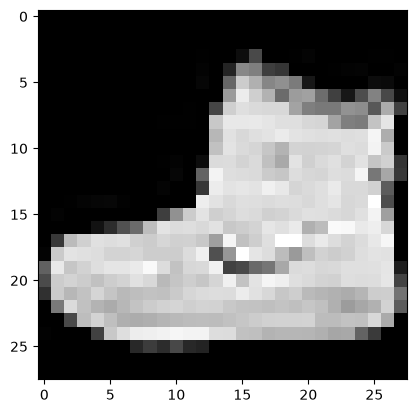

In [52]:
plt.imshow(image.squeeze(), cmap="gray")


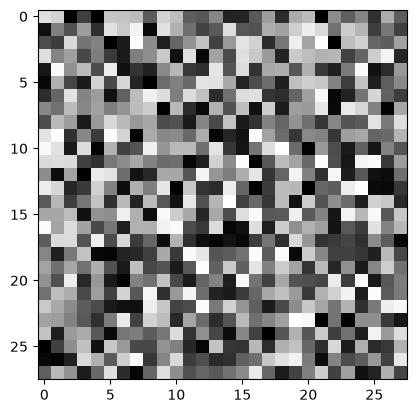

In [53]:
rand_image_tensor = torch.rand(size=(1, 28, 28))  # Random tensor with shape [channels, height, width]
rand_image = rand_image_tensor.squeeze()  # Remove the channel dimension for visualization
plt.imshow(rand_image, cmap="gray")

In [54]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

## Video Timestamp

Reference point in the source tutorial video for this section of the notebook.

- `~18:29:02` — marks the "Training and Testing Model" segment, useful for jumping back to the explanation if revisiting this notebook later